# Request Class Reduction
To streamline operations for Facilities, Custodial & Grounds (FC&P), we conducted an analysis to consolidate 400 highly granular request classes into a more manageable set of approximately 100 groups. While the original classes provide detailed descriptions of service issues, their high level of granularity can be simplified by grouping similar requests under common categories. The following sections explore two specific clustering methodologies evaluated for their ability to transform these distinct classes into semantically cohesive, broader groups that meet the project's requirements.

The first step is to read the data into the file using pandas. The provided file from FC&P was the work task (service ticket) CSV file.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_df = pd.read_csv(r'../../data/V_OM_WORK_TASK.csv')

data_df.head()

,WORK_TASK_ID,WORK_TASK_NAME,WORK_TASK_STATUS,RICE_WORK_STATUS,ASSIGNMENT_STATUS,DESCRIPTION,TASK_TYPE,TASK_PRIORITY,REQUEST_CLASS,SERVICE_CLASS,...,REVERSAL,BILLING_TYPE,ACCOUNTING_HOLD,ACCOUNTING_HOLD_REASON,COA_ACCOUNT_STRING,POETAF_ACCOUNT_STRING,NUMBER_OF_ASSETS,RESOLUTION_DESCRIPTION,CAPITAL_PROJECT_ID,CREATE_DATE_LTZ
0,1302351,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,student at Jones North room 129 has hand foot ...,Corrective,3 - Routine,Custodial Issues,Custodial,...,False,Billable,No,NaN,"10,84100,103,030000,8985,800,9999,9999,999,999",NaN,0,NaN,NaN,2025-09-19 08:24:42.000
1,1302352,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,...,False,Billable,No,NaN,"10,00100,100,000000,1087,500,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:07.000
2,1302353,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,...,False,Billable,No,NaN,"10,00100,100,000000,1087,999,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:12.000
3,1302354,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management,Capital Projects,...,False,Billable,No,NaN,"10,00100,100,000000,1087,999,9999,9999,999,999","C10000442,86000,NC Project Management Labor,No...",0,NaN,C10000442,2025-09-19 08:30:17.000
4,1302355,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,...,False,Billable,No,NaN,"10,00100,100,000000,1087,999,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:21.000


In [110]:
# Take only important columns with full set of data
data_df = data_df[
    ['REQUEST_CLASS', 'DESCRIPTION']]
data_df = data_df.dropna()
data_df.shape

(104115, 2)

In [111]:
# See how many request classes there are after light data cleaning
len(data_df['REQUEST_CLASS'].unique())

399

In [ ]:
# Take value counts of each request class to find frequency of each
class_counts = pd.DataFrame(data_df['REQUEST_CLASS'].value_counts().rename_axis('Class').reset_index(name='Counts'))


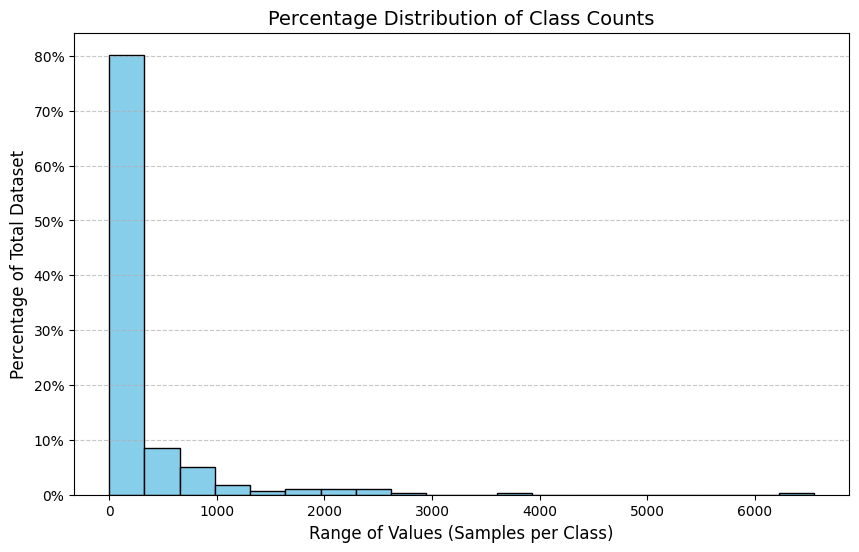

In [83]:
data = class_counts['Counts']

plt.figure(figsize=(10, 6))

plt.hist(data, bins=20, edgecolor='black', color='skyblue', 
         weights=np.ones(len(data)) / len(data))

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.title('Percentage Distribution of Class Counts', fontsize=14)
plt.xlabel('Range of Values (Samples per Class)', fontsize=12)
plt.ylabel('Percentage of Total Dataset', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Based on the distribution shown, it is evident that the majority of request classes are relatively sparse, with fewer than 250 samples each. This highlights a significant imbalance in the dataset, where a few highly frequent classes may dominate the sample count, while a "long tail" of specialized or rare request types contains much lower volumes of data. Such a distribution further justifies the need for clustering, as grouping these low-volume, granular classes can create more robust, statistically significant categories for analysis.

# K-Means Classifier

For our initial classification approach, we will implement a K-means clustering algorithm. To prepare our inputs, we will extract the top five words by frequency for each request class and encode them into a single weighted vector using a Sentence Transformer. This transform converts categorical text data into a dense numerical space, allowing the model to calculate semantic similarities. Once the model is fitted, we will evaluate its performance using the Within-Cluster Sum of Squares (WCSS). By plotting these values, we aim to identify the "elbow point", or the optimal number of clusters where we achieve the best balance between data compression and cluster cohesion.

Our first task is to load the dataset and organize the vocabulary by request class. We will utilize a pre-processed file containing the top five most frequent words and their respective counts for each class, which will serve as the foundation for our weighted embeddings.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

k_df = pd.read_csv(r'C:../../data/Top5Words_x_RequestClass.csv')

k_df.head(10)


,REQUEST_CLASS,WORD,COUNT
0,ADA Door Not Working,door,318
1,ADA Door Not Working,working,156
2,ADA Door Not Working,ada,140
3,ADA Door Not Working,open,104
4,ADA Door Not Working,button,87
5,Access Control (Keys/Card Readers),key,274
6,Access Control (Keys/Card Readers),door,164
7,Access Control (Keys/Card Readers),lost,114
8,Access Control (Keys/Card Readers),lock,89
9,Access Control (Keys/Card Readers),keys,78


As seen above, we will need to group the words by request class.


In [104]:
# Group the words and counts into a list by request class
grouped_df = k_df.groupby('REQUEST_CLASS').agg({'WORD': list, 'COUNT': list}).reset_index()
grouped_df.head()

,REQUEST_CLASS,WORD,COUNT
0,ADA Door Not Working,"[door, working, ada, open, button]","[318, 156, 140, 104, 87]"
1,Access Control (Keys/Card Readers),"[key, door, lost, lock, keys]","[274, 164, 114, 89, 78]"
2,Access Control/Security,"[door, core, construction, cores, green]","[24, 21, 18, 17, 16]"
3,Adjust Bed Height,"[bed, height, loft, lofted, lower]","[85, 33, 15, 14, 13]"
4,Admin Activity,"[labor, administrative, created, annually, parts]","[86, 85, 82, 82, 82]"


In this stage, we utilize a Sentence Transformer to convert the selected text into numerical vectors suitable for clustering algorithms. By projecting the top five words of each request class into a dense vector space, we capture the semantic meaning behind the labels.

To ensure the most frequent terms exert a stronger influence on the resulting category, we apply a weighted average based on word frequency. This approach prevents rare keywords from skewing the cluster centers, ensuring that the final numerical representation accurately reflects the primary intent of each request class.

In [91]:
# Encode the words and take the weighted avg per class
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create a word to vector map
all_unique_words = k_df['WORD'].unique().tolist()
word_to_embedding = dict(zip(all_unique_words, model.encode(all_unique_words)))

def get_weighted_embedding(row):
    words = row['WORD']
    counts = np.array(row['COUNT'])
    
    embeddings = np.array([word_to_embedding[w] for w in words])
    
    weighted_vec = np.average(embeddings, axis=0, weights=counts)
    return weighted_vec

grouped_df['weighted_vector'] = grouped_df.apply(get_weighted_embedding, axis=1)

# Stack all vectors into a single matrix
X = np.stack(grouped_df['weighted_vector'].values)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [93]:
# Here we can see the single weighted vector per request class
grouped_df[['REQUEST_CLASS', 'weighted_vector']].head()


,REQUEST_CLASS,weighted_vector
0,ADA Door Not Working,"[-0.047241745528227054, 0.008644505245437533, ..."
1,Access Control (Keys/Card Readers),"[-0.03382743536514102, 0.008830907345335022, -..."
2,Access Control/Security,"[-0.030830864154268056, 0.022349117726359207, ..."
3,Adjust Bed Height,"[0.032208796497434376, 0.03158988111536019, -0..."
4,Admin Activity,"[-0.038050157578586104, 0.015045466133766323, ..."


In [102]:
# And here we can see the stacked matrix of vectors
X

array([[-0.04724175,  0.00864451, -0.04275164, ...,  0.0235741 ,
        -0.00388632,  0.0226418 ],
       [-0.03382744,  0.00883091, -0.04195252, ..., -0.00808463,
        -0.05993927,  0.01468851],
       [-0.03083086,  0.02234912, -0.03655885, ..., -0.00890291,
         0.04125254,  0.05054367],
       ...,
       [-0.01619198,  0.03877872, -0.01147037, ..., -0.01929337,
         0.07841464,  0.06132728],
       [-0.01573196, -0.00082061, -0.02465172, ...,  0.06287305,
        -0.0191353 ,  0.08825387],
       [-0.009513  ,  0.0349999 , -0.02379893, ...,  0.08636253,
        -0.00424273,  0.04034885]], shape=(385, 384))

With our weighted vectors prepared, we now initialize the K-Means algorithm. Since our primary goal is to consolidate the 400 original request classes into the specific target requested by FC&P, we set the n_clusters parameter to 100.

By executing the model, the algorithm iteratively partitions the data, assigning each request class to the cluster whose centroid represents the nearest semantic mean. This process transforms our high-dimensional word embeddings into 100 distinct groups, effectively mapping the granular service tickets into a more manageable and streamlined classification system.

In [112]:
# Now run K-Means on the vectorized word matrix 
kmeans = KMeans(n_clusters=100, random_state=0, n_init='auto')

grouped_df['cluster'] = kmeans.fit_predict(X)

print("Cluster Centers:\n", kmeans.cluster_centers_)
print("Labels:\n", kmeans.labels_)

Cluster Centers:
 [[ 0.006296    0.00718299  0.00026552 ... -0.00017078  0.00716639
   0.00297763]
 [-0.02373133  0.0286564  -0.03242715 ...  0.03466585  0.0108499
  -0.00354565]
 [-0.01902651  0.0521971  -0.01453488 ...  0.04762964  0.01768756
  -0.01796868]
 ...
 [-0.04341072  0.02395512 -0.01081548 ... -0.03406334  0.0236207
   0.00669841]
 [-0.04713683  0.03616955  0.00839027 ... -0.00550114 -0.02794073
   0.02248376]
 [-0.04910879  0.06004115 -0.0114615  ... -0.01987108  0.00802078
   0.02697788]]
Labels:
 [17 46 78 28 68  6  6  6 31  6  6 87 17 34 21 39 39 74 74 74 65 65 65 21
 72 36  3  3 98 13 28 32 43 43 37 16 67 92  9  9  9 92 92 92 92 92  7 60
 60 60 22  8  8  8  8  8 22 22 82 71 10 25 52 50 10 48 63 63 38 71 10 10
 30 96 26  3 47 49 49 57 29 57 57 18 91 23 84 84 46 46 46 46 22 22 69 44
 10 10 34 34 10 41 93 91 56 17 17 17 55 31 10 44 50 21 16 16 16 23 27 13
 23 60 13 23 13 26 17 13 51 31 38 12 36  9  3  7  4 18 63 62 37 16 17  5
  5 21 18 18 66 86  3  7 40 18  8 10 51 36 55

In [114]:
grouped_df = grouped_df.sort_values(by='cluster')
grouped_df[['REQUEST_CLASS', 'cluster']].head(20)

,REQUEST_CLASS,cluster
211,Lawn Care - Seed/Sod/Renovate,0
323,Residential Other Furniture,1
249,Other Furniture,1
326,Residential Repair Furniture,1
232,Missing Furniture,1
224,Mark Irrigation and Utilities Lines,2
349,Sports Turf - Line and Mark,2
26,Building Exterior,3
246,Other Carpentry,3
260,Painting,3


In this step, we apply Principal Component Analysis (PCA) to condense our high-dimensional feature space. While the resulting principal components may lack interpretability since they are abstract linear combinations of many underlying variables, this transformation is a crucial part for data visualization.

In [115]:
# Apply PCA to visualize the data on a two dimensional plot
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

grouped_df['x'] = coords[:, 0]
grouped_df['y'] = coords[:, 1]

centroids_2d = pca.transform(kmeans.cluster_centers_)

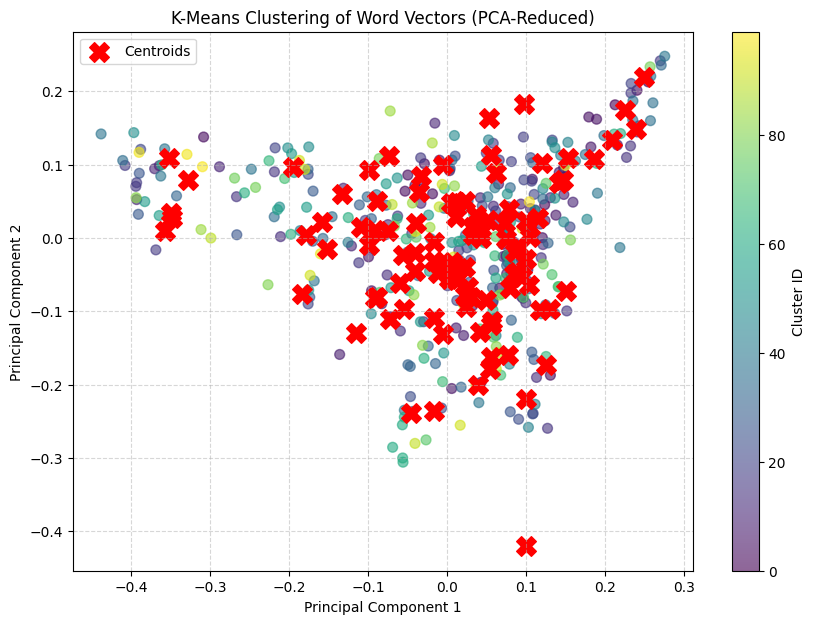

In [116]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

scatter = plt.scatter(grouped_df['x'], grouped_df['y'], 
                      c=grouped_df['cluster'], 
                      cmap='viridis', s=50, alpha=0.6)

plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
            marker='X', s=200, c='red', label='Centroids')

plt.colorbar(scatter, label='Cluster ID')

plt.title('K-Means Clustering of Word Vectors (PCA-Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

As illustrated above, while the cluster centroids successfully align with the general distribution of the data, the distinct boundaries between clusters are not immediately obvious through visualization alone. To gain a more objective understanding of the model's effectiveness, we can look beyond visual inspection and utilize the Within-Cluster Sum of Squares (WCSS).

The WCSS metric quantifies the "tightness" of each cluster by measuring the distance between data points and their respective centroids. A lower WCSS score indicates more compact, well-defined clusters, providing a mathematical confirmation of the model’s performance even when the clusters are difficult to distinguish visually. We will use the elbow method to attempt to find an ideal cluster number.

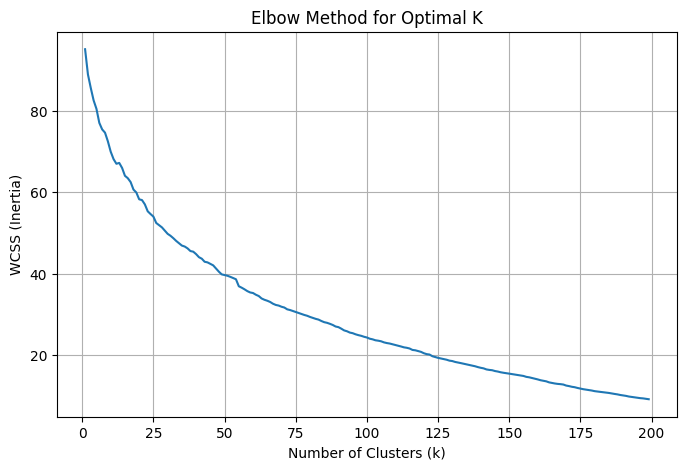

In [117]:
# Take the WCSS score from 1 to 200 clusters
wcss = []
k_range = range(1, 200)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

As shown in the plot, the WCSS curve fails to display a clear inflection point, or "elbow," which typically signals the optimal balance between compression and accuracy. This highlights a fundamental trade-off in our clustering strategy: while increasing the number of clusters K consistently improves "tightness," an excessive amount of clusters defeats the primary goal of dimensionality reduction.

To achieve highly granular, "well-defined" clusters, we would need to maintain a high K value, resulting in negligible data consolidation. Conversely, to achieve meaningful class reduction, we must accept "looser" clusters with higher internal variance. We must therefore select a cluster count that balances a manageable number of categories with a statistically acceptable level of cohesion.

In [ ]:
result_df = grouped_df.sort_values('cluster')
result_df.to_csv('clusters.csv')

# Hierarchical clustering

Building on our K-means analysis, we will now implement Agglomerative Hierarchical Clustering. Unlike the partitioning approach of K-means, this model follows a "bottom-up" logic: it begins by treating every individual request class as its own distinct cluster. The algorithm then iteratively merges the most similar clusters based on a specified distance metric until the entire dataset is unified into a single hierarchical structure. There is no predefined K clusters, rather a dendrogram structure that can show the breakdown of individual classes before they are grouped together at every level.

To maintain consistency across our experiments, we will follow the same data pipeline established in the previous section. This involves loading the dataset, sorting the vocabulary, and transforming the top five words per class into weighted vectors for the model to process.

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

h_df = pd.read_csv(r'C:../../data/Top5Words_x_RequestClass.csv')

h_df.head()

,REQUEST_CLASS,WORD,COUNT
0,ADA Door Not Working,door,318
1,ADA Door Not Working,working,156
2,ADA Door Not Working,ada,140
3,ADA Door Not Working,open,104
4,ADA Door Not Working,button,87


In [120]:
# As seen above, we will need to group the words by request class
grouped_df = h_df.groupby('REQUEST_CLASS').agg({'WORD': list, 'COUNT': list}).reset_index()
grouped_df.head()


,REQUEST_CLASS,WORD,COUNT
0,ADA Door Not Working,"[door, working, ada, open, button]","[318, 156, 140, 104, 87]"
1,Access Control (Keys/Card Readers),"[key, door, lost, lock, keys]","[274, 164, 114, 89, 78]"
2,Access Control/Security,"[door, core, construction, cores, green]","[24, 21, 18, 17, 16]"
3,Adjust Bed Height,"[bed, height, loft, lofted, lower]","[85, 33, 15, 14, 13]"
4,Admin Activity,"[labor, administrative, created, annually, parts]","[86, 85, 82, 82, 82]"


Once again, in this stage, we utilize a Sentence Transformer to convert the selected text into numerical vectors suitable for clustering algorithms. By projecting the top five words of each request class into a dense vector space, we capture the semantic meaning behind the labels.

To ensure the most frequent terms exert a stronger influence on the resulting category, we apply a weighted average based on word frequency. This approach prevents rare keywords from skewing the cluster centers, ensuring that the final numerical representation accurately reflects the primary intent of each request class.

In [121]:
# Encode the words and take the weighted avg per class
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create a word to vector map
all_unique_words = h_df['WORD'].unique().tolist()
word_to_embedding = dict(zip(all_unique_words, model.encode(all_unique_words)))

def get_weighted_embedding(row):
    words = row['WORD']
    counts = np.array(row['COUNT'])
    
    embeddings = np.array([word_to_embedding[w] for w in words])
    
    weighted_vec = np.average(embeddings, axis=0, weights=counts)
    return weighted_vec


grouped_df['weighted_vector'] = grouped_df.apply(get_weighted_embedding, axis=1)

# stack all vectors into a single matrix
X = np.stack(grouped_df['weighted_vector'].values)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [122]:
# Here we can see the single weighted vector per request class
grouped_df[['REQUEST_CLASS', 'weighted_vector']].head()

,REQUEST_CLASS,weighted_vector
0,ADA Door Not Working,"[-0.047241745528227054, 0.008644505245437533, ..."
1,Access Control (Keys/Card Readers),"[-0.03382743536514102, 0.008830907345335022, -..."
2,Access Control/Security,"[-0.030830864154268056, 0.022349117726359207, ..."
3,Adjust Bed Height,"[0.032208796497434376, 0.03158988111536019, -0..."
4,Admin Activity,"[-0.038050157578586104, 0.015045466133766323, ..."


In [124]:
# And here we can see the stacked matrix of vectors
X

array([[-0.04724175,  0.00864451, -0.04275164, ...,  0.0235741 ,
        -0.00388632,  0.0226418 ],
       [-0.03382744,  0.00883091, -0.04195252, ..., -0.00808463,
        -0.05993927,  0.01468851],
       [-0.03083086,  0.02234912, -0.03655885, ..., -0.00890291,
         0.04125254,  0.05054367],
       ...,
       [-0.01619198,  0.03877872, -0.01147037, ..., -0.01929337,
         0.07841464,  0.06132728],
       [-0.01573196, -0.00082061, -0.02465172, ...,  0.06287305,
        -0.0191353 ,  0.08825387],
       [-0.009513  ,  0.0349999 , -0.02379893, ...,  0.08636253,
        -0.00424273,  0.04034885]], shape=(385, 384))

Having established our weighted vectors, we will now initialize the Agglomerative Hierarchical Clustering algorithm. In contrast to the fixed partitions of K-means, this hierarchical approach generates a dendrogram—a tree-like visualization that maps the consolidation of the 400 original request classes as they merge into a single, unified cluster. This structure allows for an interactive analysis of the data at any level, providing transparency into exactly which classes reside within a specific group.

To optimize these merges, we will employ the 'ward' linkage method. This criterion operates by minimizing the variance within each group; specifically, it calculates the distance between clusters based on the potential increase in the Total Within-Cluster Sum of Squares (ESS) that would result from their merger. By selecting this method, we aim to produce semantically "tight" and logical clusters, such as the plumbing and infrastructure families, while utilizing the algorithm's automated coloring scheme to highlight the most naturally occurring groupings within the hierarchy.

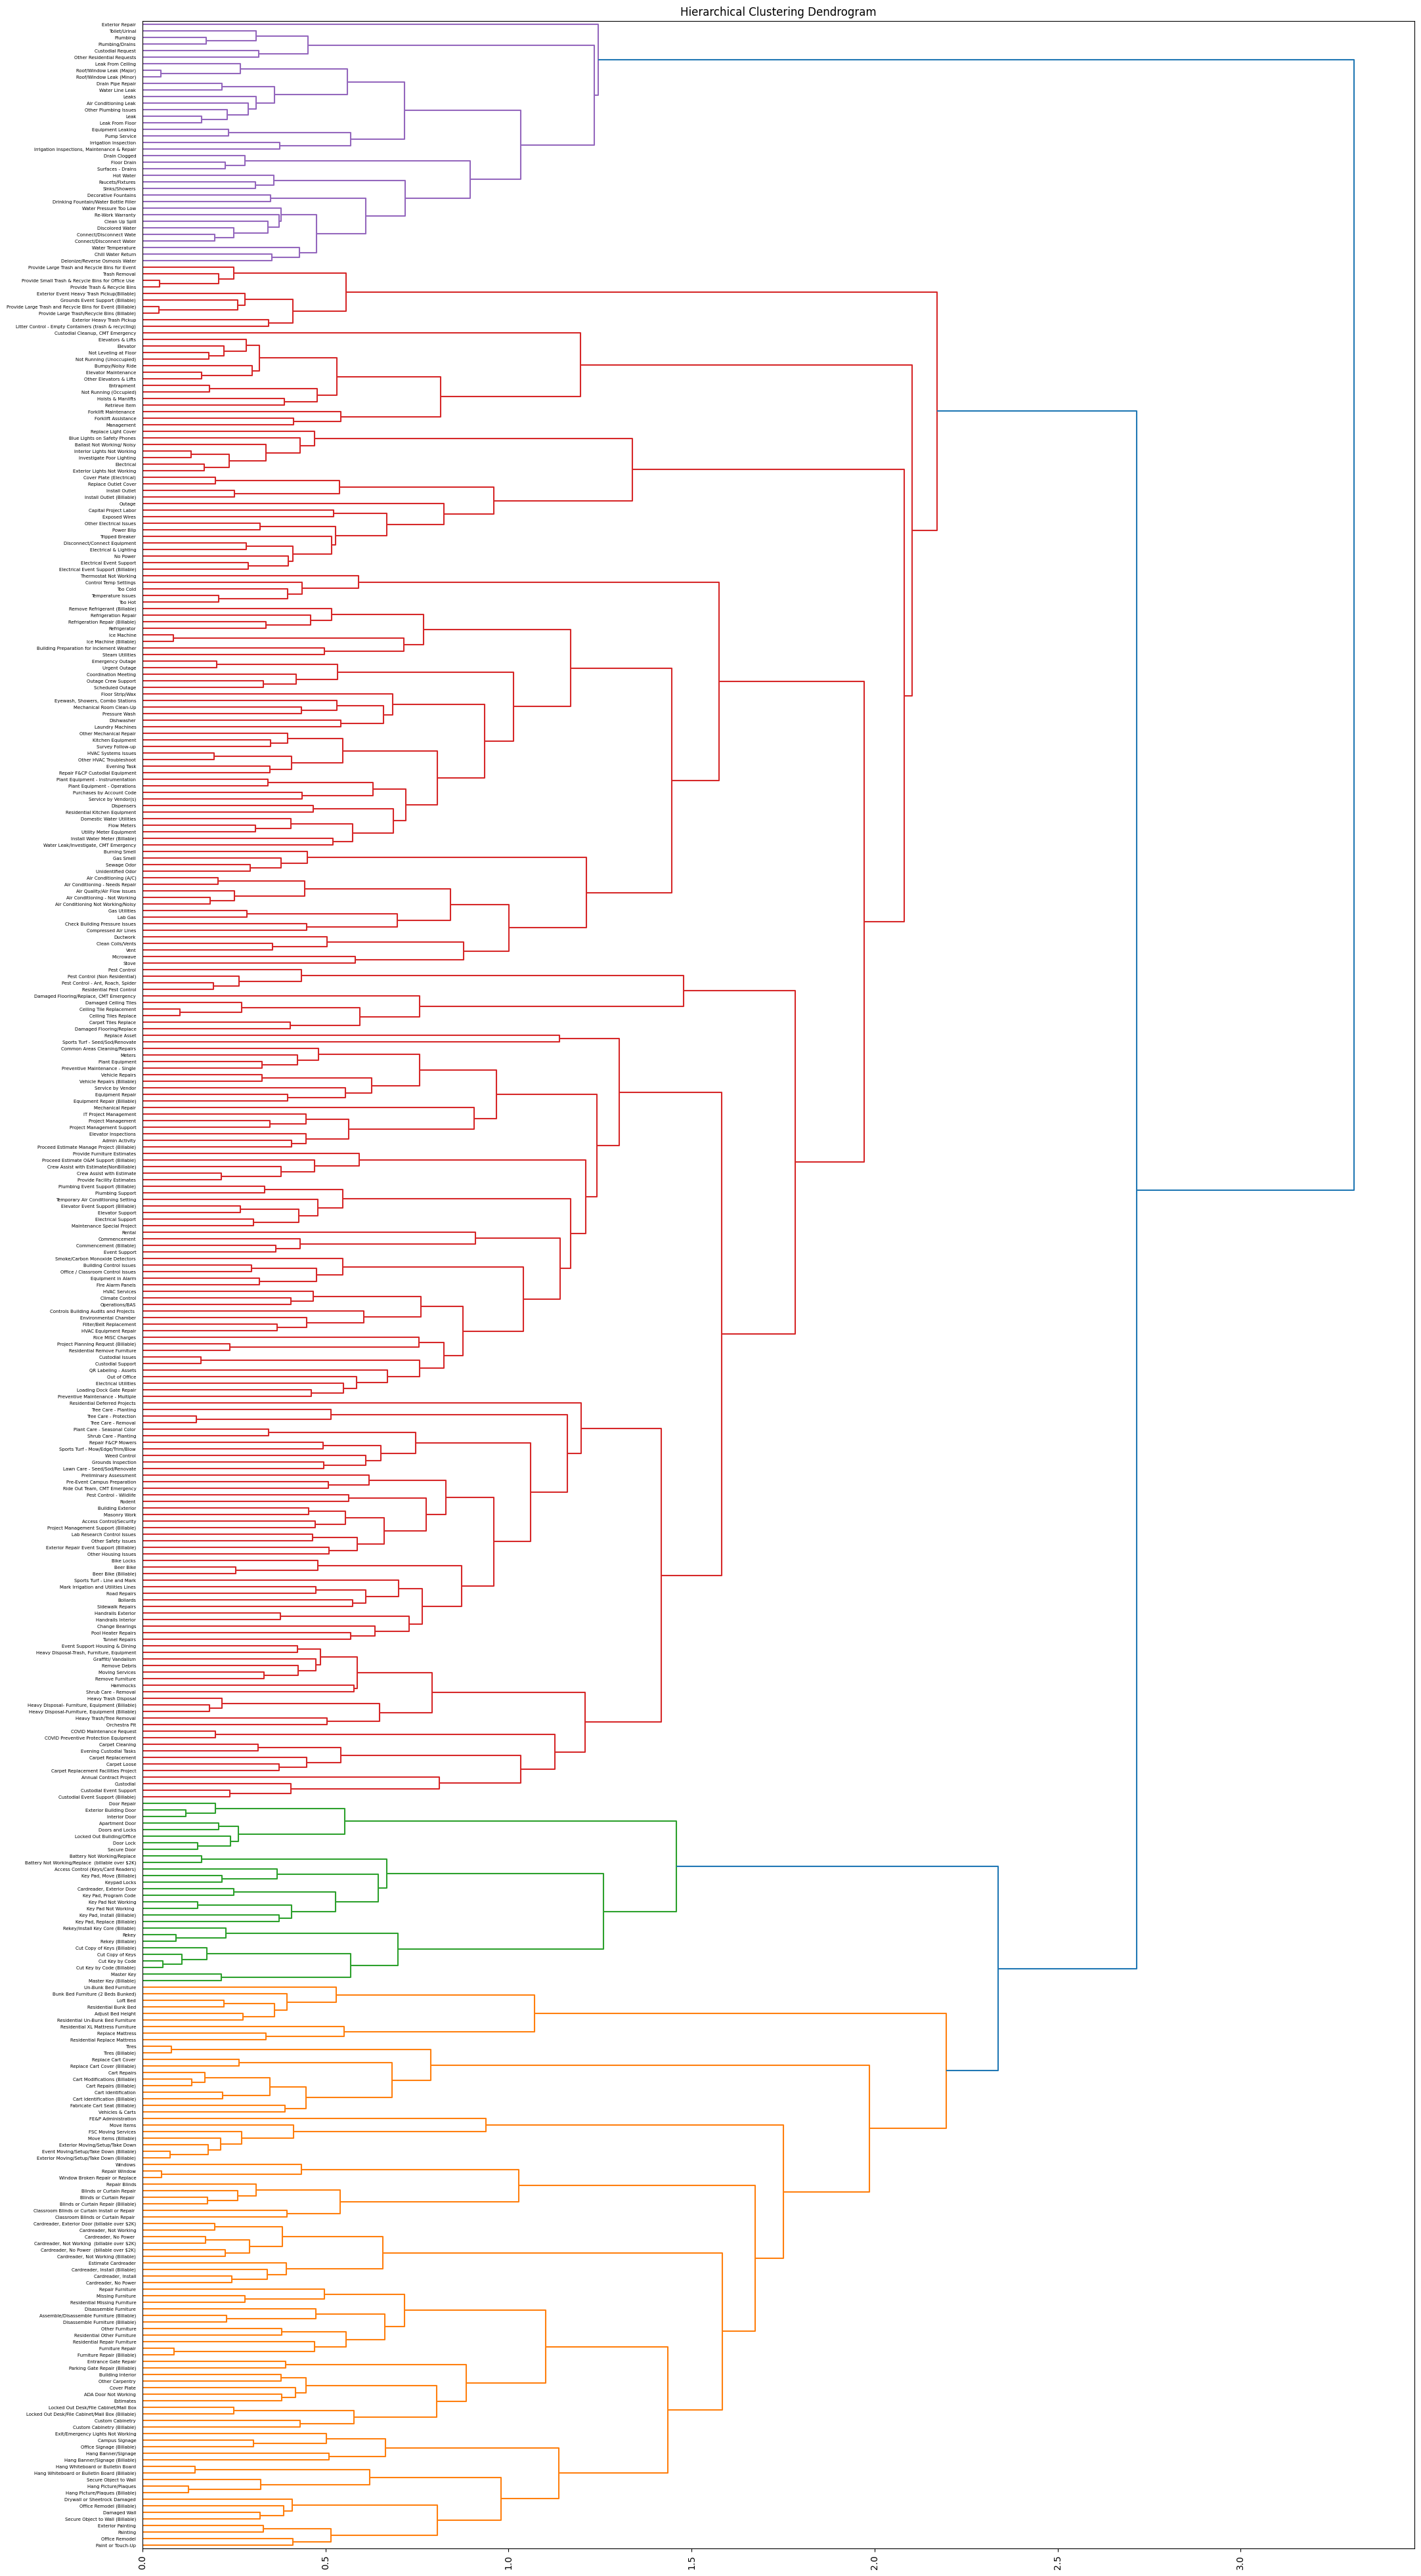

In [125]:
# Now run linkage on the vectorized word matrix using the 'ward' and plot
linked = linkage(X, method='ward')

plt.figure(figsize=(25, 50))
dendrogram(linked,
           orientation='right',
           labels=grouped_df['REQUEST_CLASS'].values, 
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xticks(rotation=90)
plt.show()

The visualization above reveals a high-level breakdown of the request classes, where the algorithm has identified four primary macro-clusters. While these groupings may be too broad for final classification, they offer valuable insight into the semantic relationships within our data:

Purple Cluster (Plumbing): Aggregates specialized utilities such as toilets and water leakage issues.

Red Cluster (Major Infrastructure): Groups core building systems, including HVAC and Electrical requests.

Green Cluster (Access Control): Consolidates security-related classes like keycards and door locks.

Orange Cluster (General Maintenance): Captures minor structural repairs, such as wall and window maintenance.

To achieve a more granular categorization, we want to visualize the structure at a resolution of 100 clusters. By leveraging the hierarchical nature of the dendrogram, we can "slice" the tree at a specific height, treating every branch below that threshold as an independent cluster. This allows us to transition from broad categories to highly specific request groups. We can execute the following code to visualize this refined partition.

Threshold for 100 clusters: 0.65733385753388


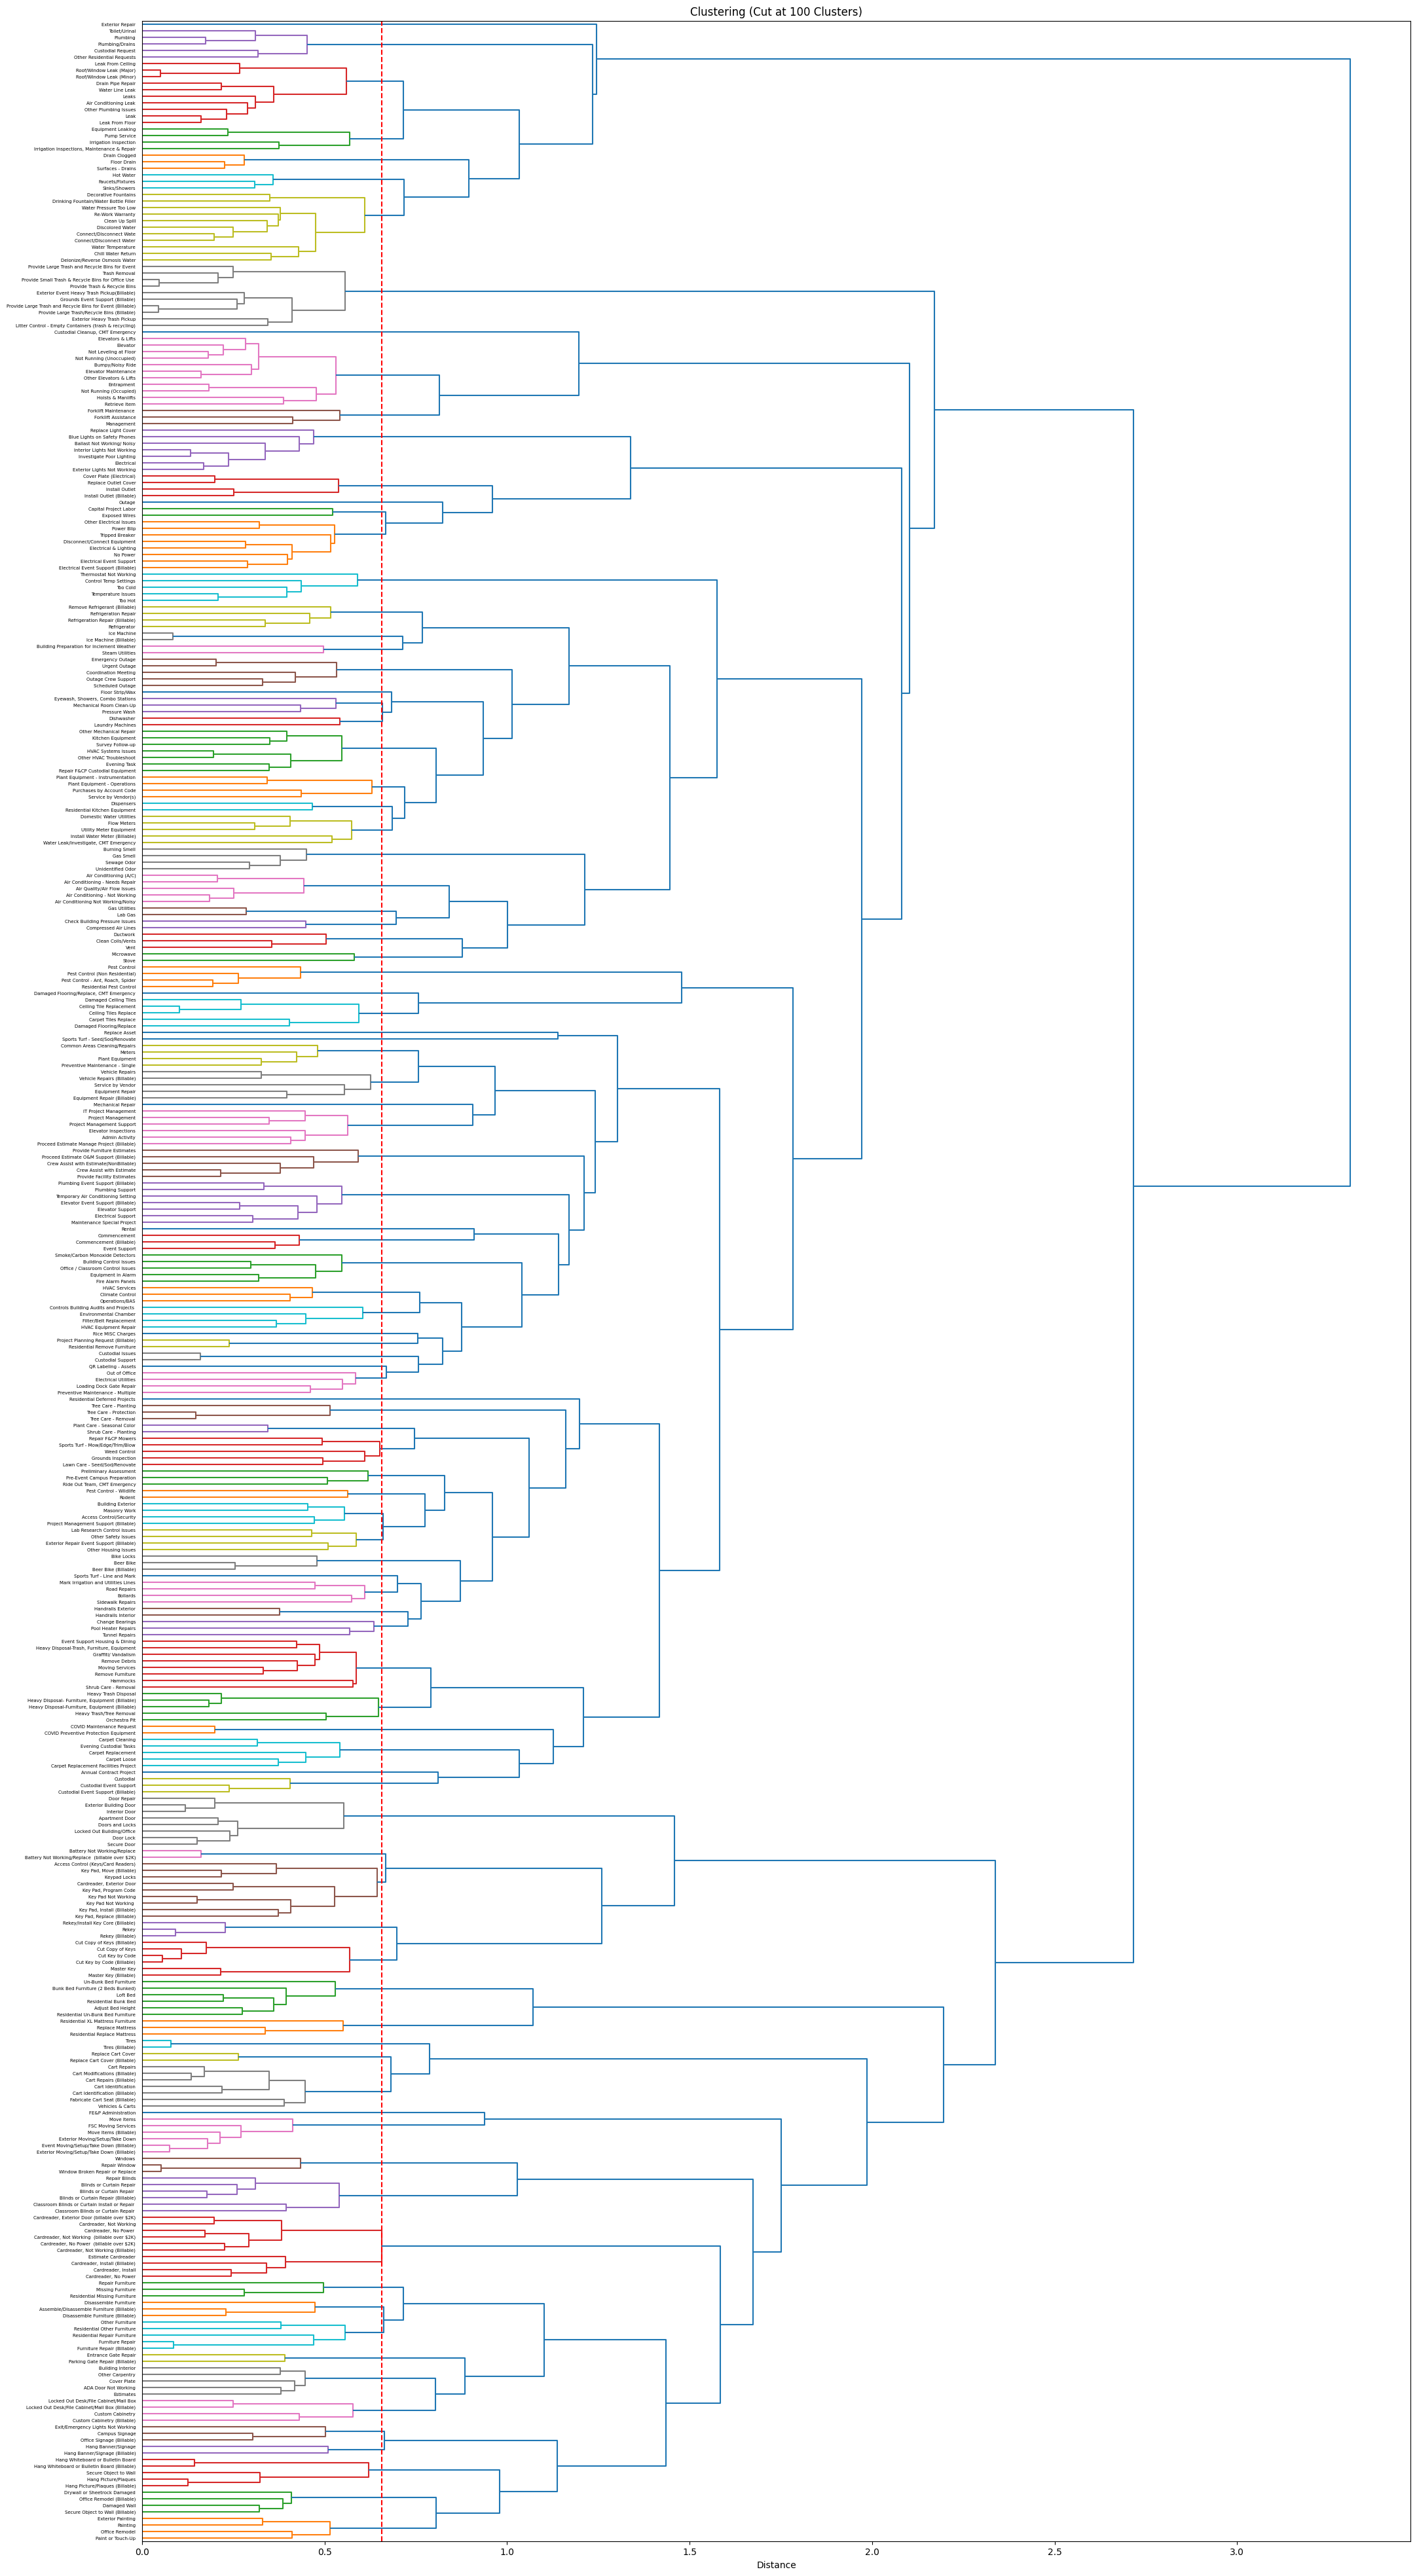

In [126]:
# 1. Get all merge distances
heights = linked[:, 2]

# 2. Define target number of clusters
n_clusters = 100

# 3. Calculate the threshold
idx = -n_clusters
# Take the average between this merge and the one above it for a clean cut
dist_threshold = (heights[idx] + heights[idx + 1]) / 2

print(f"Threshold for {n_clusters} clusters: {dist_threshold}")

# 4. Plot
plt.figure(figsize=(25, 50))
dendrogram(
    linked,
    orientation='right',
    labels=grouped_df['REQUEST_CLASS'].values,
    distance_sort='descending',
    color_threshold=dist_threshold,
    show_leaf_counts=True
)

plt.axvline(x=dist_threshold, color='r', linestyle='--')

plt.title(f'Clustering (Cut at {n_clusters} Clusters)')
plt.xlabel('Distance')
plt.show()

We can observe the hierarchical breakdown of the request classes when the tree is partitioned into 100 distinct groups. The vertical dashed red line illustrates the precise "cut" point; every horizontal branch intersecting this line on the left represents an individual cluster grouping.The primary advantage of the hierarchical method is its inherent flexibility. Unlike K-means, which requires a fixed K value from the start, the dendrogram allows us to dynamically adjust our resolution. By slightly shifting the "cut" line, we can seamlessly observe how the groupings would change if we targeted 97, 98, or even 102 clusters. This provides a continuous view of the data's structure, making it much easier to fine-tune the balance between category reduction and semantic detail.

To fulfill the objective of reducing the request classes into the 100 groups requested by FC&P, we utilize the hierarchical structure provided by the dendrogram. This visualization allows us to see how the diverse range of building and maintenance tasks can be systematically consolidated.